# Классификация городских эпидемических волн по форме синтетических кривых

Ноутбук идёт сверху вниз: сначала читаем синтетические SEIR-траектории, смотрим на них, извлекаем признаки формы и обучаем классификатор. Затем читаем городские недельные ряды, находим волны и сравниваем их раннюю форму с синтетическими классами.

# 1. Импорты и параметры

In [55]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
SPLITS_DIR = DATA_DIR / 'splits'
CITY_DATA_PATH = DATA_DIR / 'indices_in_big_cities.csv'

RANDOM_STATE = 42
GRAPH_KINDS = {'barabasi_albert_graph', 'watts_strogatz_graph'}

# Синтетика измеряется в днях: 35 до пика + 14 после дают 49 точек.
SYNTHETIC_DAYS_BEFORE_PEAK = 35
SYNTHETIC_DAYS_AFTER_PEAK = 14
SYNTHETIC_WINDOW_POINTS = SYNTHETIC_DAYS_BEFORE_PEAK + SYNTHETIC_DAYS_AFTER_PEAK

CITY_START_YEAR = 2009
EPIDEMIC_MARKS = {'Э'}
# Городские данные идут по неделям: 5 до пика + 2 после дают 7 точек.
CITY_WEEKS_BEFORE_PEAK = 5
CITY_WEEKS_AFTER_PEAK = 2
CITY_WINDOW_POINTS = CITY_WEEKS_BEFORE_PEAK + CITY_WEEKS_AFTER_PEAK

TRAIN_SIZE = 0.60
VAL_SIZE = 0.20
TEST_SIZE = 0.20
MIN_CLASS_RECALL_FOR_ACCEPTANCE = 1e-12

# 2. Загрузка синтетических кривых

In [41]:
def clean_curve(y):
    """Приводит ряд к числам, убирает пропуски и отрицательные значения."""
    #arr = pd.to_numeric(pd.Series(y), errors='coerce').replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    arr = pd.Series(y).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    arr[arr < 0] = 0
    return arr


def normalize_curve(y):
    """Нормируем ряд"""
    arr = clean_curve(y)
    if arr.size == 0 or np.nanmax(arr) <= 0:
        return np.zeros_like(arr, dtype=float)
    return arr / np.nanmax(arr)


def curve_window_around_peak(y, points_before_peak, points_after_peak):
    """Возвращает фиксированное окно вокруг пика или пустой ряд, если окно не помещается."""
    arr = clean_curve(y)
    if arr.size == 0 or np.nanmax(arr) <= 0:
        return arr[:0], 0, -1

    normalized = normalize_curve(arr)
    peak_idx = int(np.argmax(normalized))
    start_idx = peak_idx - points_before_peak
    end_exclusive = peak_idx + points_after_peak

    if start_idx < 0 or end_exclusive > arr.size:
        return arr[:0], max(0, start_idx), min(arr.size - 1, end_exclusive - 1)

    return arr[start_idx:end_exclusive], start_idx, end_exclusive - 1

In [42]:
synthetic_records = []

for split_name in ['train', 'val', 'test']:
    split_dir = SPLITS_DIR / split_name
    index_df = pd.read_csv(split_dir / f'{split_name}_index.csv')

    for row in index_df.itertuples(index=False):
        source_path = row.initial
        graph_match = re.search(r'simulations[\/]+([^\/]+)[\/]+', source_path)
        lam_match = re.search(r'lam=([^\/]+)', source_path)
        graph_kind = graph_match.group(1) if graph_match else None

        if graph_kind not in GRAPH_KINDS:
            continue

        curve_path = split_dir / f'seir_seed_{int(row.finite)}.csv'
        curve_df = pd.read_csv(curve_path)
        comparison_curve, start_idx, end_idx = curve_window_around_peak(
            curve_df['I'],
            SYNTHETIC_DAYS_BEFORE_PEAK,
            SYNTHETIC_DAYS_AFTER_PEAK,
        )

        if comparison_curve.size != SYNTHETIC_WINDOW_POINTS or np.nanmax(comparison_curve) <= 0:
            continue

        synthetic_records.append({
            'source_split': split_name,
            'label': graph_kind,
            'graph_kind': graph_kind,
            'lam': pd.to_numeric(lam_match.group(1), errors='coerce') if lam_match else np.nan,
            #'finite_file': curve_path.name,
            #'curve_path': str(curve_path),
            #'source_relative_path': source_path,
            'comparison_start_idx': start_idx,
            'comparison_end_idx': end_idx,
            'comparison_curve': comparison_curve,
        })

synthetic_features = pd.DataFrame(synthetic_records)
print(f'Загружено синтетических участков: {len(synthetic_features):,}')
display(synthetic_features.groupby(['source_split', 'label']).size().unstack(fill_value=0))
display(synthetic_features.groupby(['label', 'lam']).size().rename('n').reset_index())

Загружено синтетических участков: 58


label,barabasi_albert_graph,watts_strogatz_graph
source_split,,
test,10,2
train,31,6
val,7,2


,label,lam,n
0,barabasi_albert_graph,4,48
1,watts_strogatz_graph,16,10


## 3. Первичный взгляд на синтетику

Перед признаками полезно увидеть сами формы: сколько данных есть в каждом классе и как выглядят ранние участки до пика.

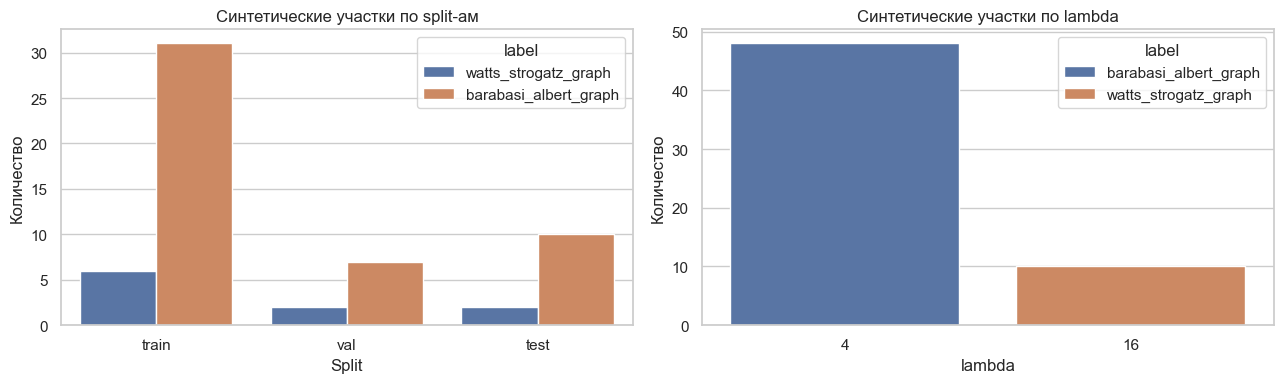

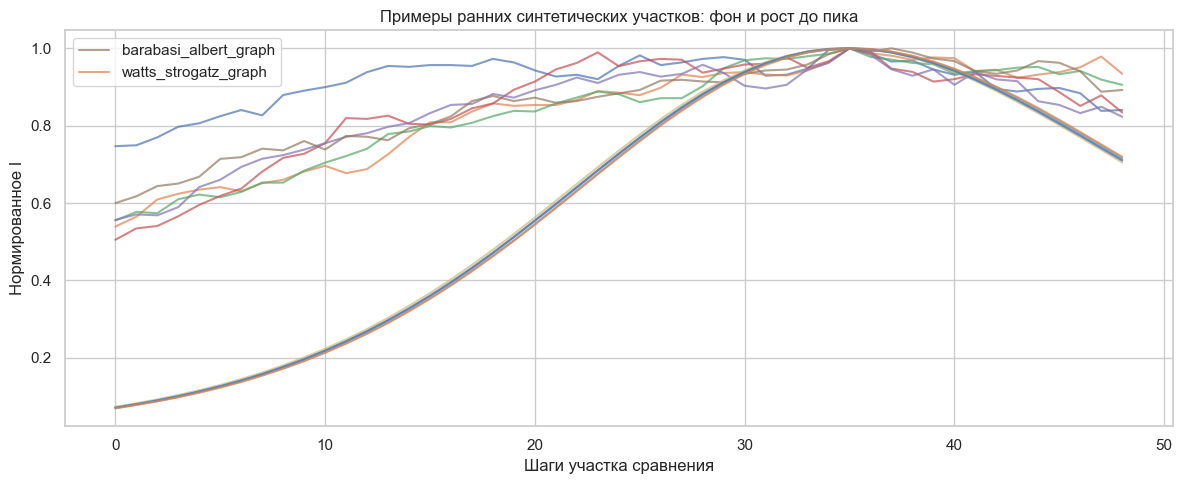

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=synthetic_features, x='source_split', hue='label', ax=axes[0])
axes[0].set_title('Синтетические участки по split-ам')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Количество')

sns.countplot(data=synthetic_features, x='lam', hue='label', ax=axes[1])
axes[1].set_title('Синтетические участки по lambda')
axes[1].set_xlabel('lambda')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

sample_curves = synthetic_features.groupby('label', group_keys=False).sample(n=6, random_state=RANDOM_STATE)
plt.figure(figsize=(12, 5))
for row in sample_curves.itertuples(index=False):
    plt.plot(normalize_curve(row.comparison_curve), alpha=0.7, label=row.label)
handles, labels = plt.gca().get_legend_handles_labels()
unique = dict(zip(labels, handles))
plt.title('Примеры ранних синтетических участков: фон и рост до пика')
plt.xlabel('Шаги участка сравнения')
plt.ylabel('Нормированное I')
plt.legend(unique.values(), unique.keys())
plt.tight_layout()
plt.show()

## 4. Признаки формы

Признаки считаются на нормированной кривой, чтобы модель сравнивала форму роста, а не масштаб эпидемии.

In [44]:
def curve_features(y):
    """Считает признаки формы нормированной кривой: пик, рост, ширину и площадь."""
    raw = clean_curve(y)
    n = int(raw.size)
    if n == 0:
        return {
            'n_points': 0, 'raw_peak': 0.0, 'peak_value': 0.0,
            'duration': 0.0, 'auc': 0.0, 'max_growth': 0.0, 'max_decline': 0.0,
            'width_at_half_max': 0.0, 'early_slope': 0.0, 'num_peaks': 0,
            'mean_value': 0.0, 'std_value': 0.0,
        }

    y_norm = normalize_curve(raw)
    peak_idx = int(np.argmax(y_norm))
    denom = max(n - 1, 1)
    diff = np.diff(y_norm) if n > 1 else np.array([0.0])
    half = np.where(y_norm >= 0.5)[0]

    # Ранний наклон считаем по первым 20% участка, но минимум по 3 точкам.
    early_window = max(3, min(n, int(np.ceil(n * 0.2))))
    early_y = y_norm[:early_window]
    early_slope = 0.0
    if early_window >= 2 and np.std(early_y) > 0:
        early_slope = float(np.polyfit(np.arange(early_window, dtype=float), early_y, 1)[0])

    # Локальные пики помогают отличать гладкий рост от более рваных участков.
    num_peaks = 0
    for i in range(1, n - 1):
        is_peak = y_norm[i] >= y_norm[i - 1] and y_norm[i] >= y_norm[i + 1]
        is_prominent = y_norm[i] - min(y_norm[i - 1], y_norm[i + 1]) >= 0.05
        num_peaks += int(is_peak and is_prominent)

    return {
        'n_points': n,
        'raw_peak': float(np.max(raw)),
        'peak_value': float(np.max(y_norm)),
        'duration': float(np.sum(y_norm > 0.05) / n),
        'auc': float(np.trapz(y_norm) / denom) if n > 1 else float(y_norm[0]),
        'max_growth': float(np.max(diff)) if diff.size else 0.0,
        'max_decline': float(abs(np.min(diff))) if diff.size else 0.0,
        'width_at_half_max': float((half[-1] - half[0] + 1) / n) if half.size else 0.0,
        'early_slope': early_slope,
        'num_peaks': int(num_peaks),
        'mean_value': float(np.mean(y_norm)),
        'std_value': float(np.std(y_norm)),
    }

feature_df = pd.DataFrame([curve_features(curve) for curve in synthetic_features['comparison_curve']])
synthetic_features = pd.concat([synthetic_features.reset_index(drop=True), feature_df], axis=1)

# Эти признаки завязаны на масштаб, длину ряда или процедуру выравнивания по пику,
# поэтому исключаем их из модели формы.
EXCLUDED_MODEL_FEATURES = ['n_points', 'raw_peak', 'peak_value', 'time_to_peak']
FEATURE_COLUMNS = list(feature_df.columns)
MODEL_FEATURE_COLUMNS = [column for column in FEATURE_COLUMNS if column not in EXCLUDED_MODEL_FEATURES]

print('Признаки модели:')
display(pd.Series(MODEL_FEATURE_COLUMNS, name='feature'))
display(synthetic_features[MODEL_FEATURE_COLUMNS + ['label']].head())

Признаки модели:


0         time_to_peak
1             duration
2                  auc
3           max_growth
4          max_decline
5    width_at_half_max
6          early_slope
7            num_peaks
8           mean_value
9            std_value
Name: feature, dtype: object

,time_to_peak,duration,auc,max_growth,max_decline,width_at_half_max,early_slope,num_peaks,mean_value,std_value,label
0,0.729167,1.0,0.607195,0.043766,0.032087,0.612245,0.013915,0,0.602770,0.328084,watts_strogatz_graph
1,0.729167,1.0,0.863948,0.037037,0.043573,1.000000,0.017944,0,0.862212,0.108242,barabasi_albert_graph
2,0.729167,1.0,0.611180,0.043552,0.032324,0.612245,0.014245,0,0.606608,0.325981,watts_strogatz_graph
3,0.729167,1.0,0.880665,0.048246,0.043860,1.000000,0.019883,0,0.878804,0.116504,barabasi_albert_graph
4,0.729167,1.0,0.861225,0.053388,0.026694,1.000000,0.008910,0,0.859573,0.109361,barabasi_albert_graph


## 5. Как признаки разделяют классы

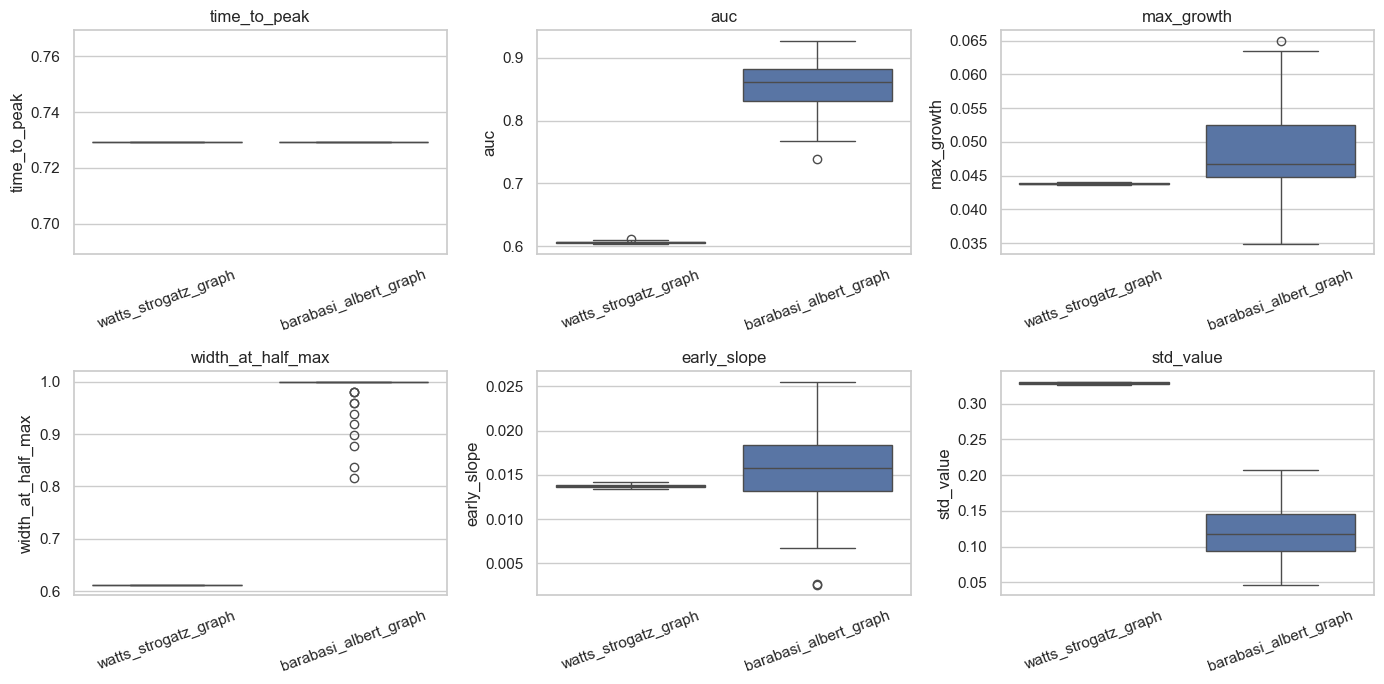

In [45]:
plot_features = ['duration', 'auc', 'max_growth', 'width_at_half_max', 'early_slope', 'std_value']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, feature in zip(axes.ravel(), plot_features):
    sns.boxplot(data=synthetic_features, x='label', y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 6. Балансировка и обучение модели

Чтобы модель не училась на перекосах lambda или класса, сначала выравниваем страты label + lambda, а потом заново делим данные на train/validation/test.

In [46]:
work = synthetic_features.copy()
work['stratify_key'] = work[['label', 'lam']].astype(str).agg('|'.join, axis=1)
strata_counts = work['stratify_key'].value_counts().sort_index()
min_stratum_size = int(strata_counts.min())

balanced = pd.concat(
    [group.sample(n=min_stratum_size, random_state=RANDOM_STATE) for _, group in work.groupby('stratify_key')],
    ignore_index=True,
)

train_df, holdout_df = train_test_split(
    balanced,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=balanced['stratify_key'],
)

val_df, test_df = train_test_split(
    holdout_df,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    random_state=RANDOM_STATE,
    stratify=holdout_df['stratify_key'],
)

train_df = train_df.assign(split='train').copy()
val_df = val_df.assign(split='val').copy()
test_df = test_df.assign(split='test').copy()
final_splits = pd.concat([train_df, val_df, test_df], ignore_index=True)

print('Размеры страт до балансировки:')
display(strata_counts.rename('before_balance').reset_index())
print('Финальное распределение split-ов по классам:')
display(final_splits.groupby(['split', 'label']).size().unstack(fill_value=0))
print('Финальное распределение split-ов по классам и lambda:')
display(final_splits.groupby(['split', 'label', 'lam']).size().rename('n').reset_index())

Размеры страт до балансировки:


,stratify_key,before_balance
0,barabasi_albert_graph|4,48
1,watts_strogatz_graph|16,10


Финальное распределение split-ов по классам:


label,barabasi_albert_graph,watts_strogatz_graph
split,,
test,2,2
train,6,6
val,2,2


Финальное распределение split-ов по классам и lambda:


,split,label,lam,n
0,test,barabasi_albert_graph,4,2
1,test,watts_strogatz_graph,16,2
2,train,barabasi_albert_graph,4,6
3,train,watts_strogatz_graph,16,6
4,val,barabasi_albert_graph,4,2
5,val,watts_strogatz_graph,16,2


In [47]:
models = {
    'logistic_regression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE)),
    ]),
    'random_forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ]),
}

model_rows = []
X_train = train_df[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
y_train = train_df['label']
X_val = val_df[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
y_val = val_df['label']

for model_name, model in models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    recalls = recall_score(y_val, val_pred, labels=model.classes_, average=None, zero_division=0)
    model_rows.append({
        'model': model_name,
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_balanced_accuracy': balanced_accuracy_score(y_val, val_pred),
        'val_f1_macro': f1_score(y_val, val_pred, average='macro'),
        'val_min_class_recall': float(np.min(recalls)),
    })

model_scores = pd.DataFrame(model_rows).sort_values(
    ['val_min_class_recall', 'val_f1_macro', 'val_balanced_accuracy', 'val_accuracy'],
    ascending=False,
)

accepted_models = model_scores[model_scores['val_min_class_recall'] > MIN_CLASS_RECALL_FOR_ACCEPTANCE]
if accepted_models.empty:
    raise ValueError('Ни одна модель не прошла validation: у одного из классов recall равен нулю.')

best_model_name = accepted_models.iloc[0]['model']
best_model = models[best_model_name]

print(f'Лучшая модель: {best_model_name}')
display(model_scores)

Лучшая модель: logistic_regression


,model,val_accuracy,val_balanced_accuracy,val_f1_macro,val_min_class_recall
0,logistic_regression,1.0,1.0,1.0,1.0
1,random_forest,1.0,1.0,1.0,1.0


## 7. Проверка на test

,test_accuracy,test_balanced_accuracy,test_macro_f1,test_min_class_recall
0,1.0,1.0,1.0,1.0


                       precision    recall  f1-score   support

barabasi_albert_graph       1.00      1.00      1.00         2
 watts_strogatz_graph       1.00      1.00      1.00         2

             accuracy                           1.00         4
            macro avg       1.00      1.00      1.00         4
         weighted avg       1.00      1.00      1.00         4



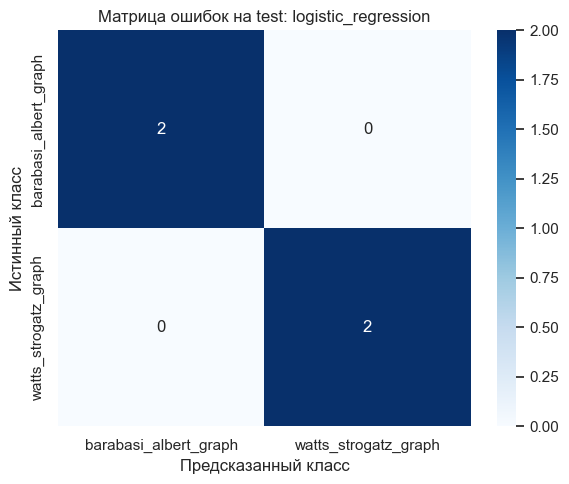

In [48]:
X_test = test_df[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
y_test = test_df['label']
test_pred = best_model.predict(X_test)
labels = list(best_model.classes_)
test_recalls = recall_score(y_test, test_pred, labels=labels, average=None, zero_division=0)

test_metrics = {
    'test_accuracy': accuracy_score(y_test, test_pred),
    'test_balanced_accuracy': balanced_accuracy_score(y_test, test_pred),
    'test_macro_f1': f1_score(y_test, test_pred, average='macro'),
    'test_min_class_recall': float(np.min(test_recalls)),
}

if test_metrics['test_min_class_recall'] <= MIN_CLASS_RECALL_FOR_ACCEPTANCE:
    raise ValueError('Выбранная модель не прошла test: у одного из классов recall равен нулю.')

display(pd.DataFrame([test_metrics]))
print(classification_report(y_test, test_pred, labels=labels, zero_division=0))

cm = confusion_matrix(y_test, test_pred, labels=labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Матрица ошибок на test: {best_model_name}')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.tight_layout()
plt.show()

## 8. Городские данные

Теперь читаем недельные городские ряды и сразу смотрим, какие города и годы доступны после 2009 года.

In [49]:
city_df = pd.read_csv(CITY_DATA_PATH, delimiter=';')
for column in ['cld_year', 'week_number', 'wd_total', 'qty_total']:
    city_df[column] = pd.to_numeric(city_df[column], errors='coerce')

city_df = (
    city_df[city_df['cld_year'] >= CITY_START_YEAR]
    .sort_values(['town_name', 'cld_year', 'week_number'])
    .reset_index(drop=True)
)

print(f'Файл городских данных: {CITY_DATA_PATH}')
print(f'Строк после {CITY_START_YEAR}: {len(city_df):,}')
print(f'Городов: {city_df["town_name"].nunique()}')

display(city_df.groupby('town_name').agg(
    rows=('wd_total', 'size'),
    non_missing_wd_total=('wd_total', lambda x: x.notna().sum()),
    first_year=('cld_year', 'min'),
    last_year=('cld_year', 'max'),
).reset_index())

Файл городских данных: c:\Users\user\Desktop\projects\topology_influences_on_disease_spread\data\indices_in_big_cities.csv
Строк после 2009: 5,004
Городов: 12


,town_name,rows,non_missing_wd_total,first_year,last_year
0,Екатеринбург,417,365,2009,2016
1,Казань,417,365,2009,2016
2,Москва,417,365,2009,2016
3,Нижний_Новгород,417,365,2009,2016
4,Новосибирск,417,365,2009,2016
5,Омск,417,365,2009,2016
6,Пермь,417,365,2009,2016
7,Ростов-на-Дону,417,365,2009,2016
8,Самара,417,365,2009,2016
9,Санкт-Петербург,417,365,2009,2016


## 9. Первичный взгляд на городские ряды

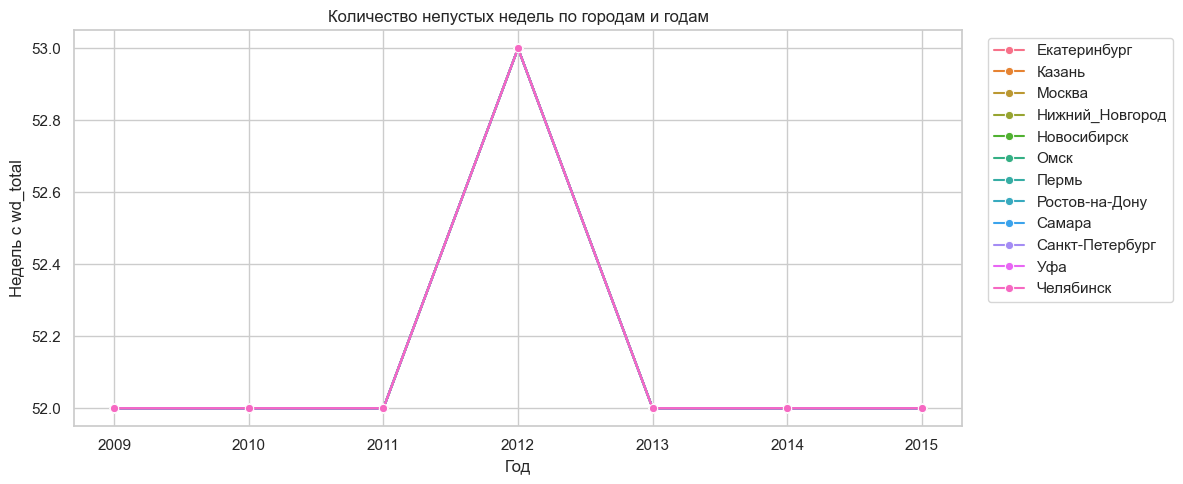

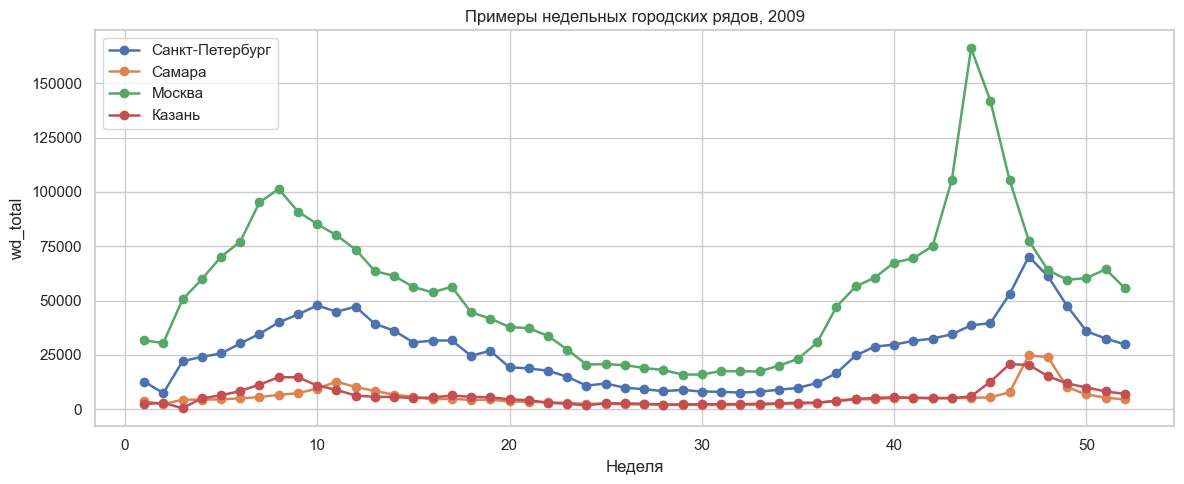

In [50]:
city_year_counts = city_df.dropna(subset=['wd_total']).groupby(['town_name', 'cld_year']).size().reset_index(name='weeks')

plt.figure(figsize=(12, 5))
sns.lineplot(data=city_year_counts, x='cld_year', y='weeks', hue='town_name', marker='o')
plt.title('Количество непустых недель по городам и годам')
plt.xlabel('Год')
plt.ylabel('Недель с wd_total')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

example_cities = ['Санкт-Петербург', 'Самара', 'Москва', 'Казань']
example_year = 2009
plt.figure(figsize=(12, 5))
for city in example_cities:
    example = city_df[(city_df['town_name'] == city) & (city_df['cld_year'] == example_year)]
    plt.plot(example['week_number'], example['wd_total'], marker='o', linewidth=1.8, label=city)
plt.title(f'Примеры недельных городских рядов, {example_year}')
plt.xlabel('Неделя')
plt.ylabel('wd_total')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Поиск городских волн

Для каждого города сглаживаем ряд, ищем локальные пики выше адаптивного порога и берём участок от небольшого фона перед ростом до пика.

In [51]:
def smooth_city_series(group):
    """Сглаживает недельный ряд города и переходит к доле заболевших, если есть население."""
    group = group.sort_values(['cld_year', 'week_number']).copy()
    y = group['wd_total'].astype(float)
    population = group['qty_total'].replace(0, np.nan).astype(float)
    if population.notna().sum() > 0:
        y = y / population
    y = y.interpolate(limit_direction='both')
    return y.rolling(window=5, center=True, min_periods=1).median().rolling(window=3, center=True, min_periods=1).mean().to_numpy(dtype=float)


def epidemic_segments(group):
    """Находит непрерывные интервалы, где wda_total помечен как эпидемия."""
    epidemic_mask = group['wda_total'].astype(str).isin(EPIDEMIC_MARKS).to_numpy()
    segments = []
    i = 0
    while i < len(epidemic_mask):
        if not epidemic_mask[i]:
            i += 1
            continue
        start = i
        while i + 1 < len(epidemic_mask) and epidemic_mask[i + 1]:
            i += 1
        end = i
        segments.append((start, end))
        i += 1
    return segments


city_wave_records = []
city_wave_curves = []
city_wave_issues = []

for city, group in city_df.groupby('town_name'):
    group = group.sort_values(['cld_year', 'week_number']).reset_index(drop=True)
    smoothed = smooth_city_series(group)
    valid = np.isfinite(smoothed) & (smoothed >= 0)

    if valid.sum() < CITY_WINDOW_POINTS or np.nanmax(smoothed[valid]) <= 0:
        city_wave_issues.append({'city': city, 'issue': 'not enough non-empty observations'})
        continue

    series = pd.Series(np.where(valid, smoothed, np.nan)).interpolate(limit_direction='both').to_numpy(dtype=float)
    waves = []

    for epidemic_start_idx, epidemic_end_idx in epidemic_segments(group):
        epidemic_segment = series[epidemic_start_idx:epidemic_end_idx + 1]
        if epidemic_segment.size == 0 or np.nanmax(epidemic_segment) <= 0:
            continue

        peak_idx = epidemic_start_idx + int(np.nanargmax(epidemic_segment))
        start_idx = peak_idx - CITY_WEEKS_BEFORE_PEAK
        end_exclusive = peak_idx + CITY_WEEKS_AFTER_PEAK

        if start_idx < 0 or end_exclusive > len(series):
            continue

        comparison_curve = series[start_idx:end_exclusive]
        if comparison_curve.size != CITY_WINDOW_POINTS or np.nanmax(comparison_curve) <= 0:
            continue

        waves.append({
            'city': city,
            'start_idx': start_idx,
            'end_idx': end_exclusive - 1,
            'peak_idx': peak_idx,
            'comparison_start_idx': start_idx,
            'comparison_end_idx': end_exclusive - 1,
            'epidemic_start_idx': epidemic_start_idx,
            'epidemic_end_idx': epidemic_end_idx,
            'peak_value': float(series[peak_idx]),
            'full_curve': comparison_curve,
            'comparison_curve': comparison_curve,
        })

    if not waves:
        city_wave_issues.append({'city': city, 'issue': 'no full fixed-length epidemic windows'})
        continue

    for wave_id, wave in enumerate(sorted(waves, key=lambda item: item['start_idx']), start=1):
        features = curve_features(wave['comparison_curve'])
        city_wave_records.append({
            **features,
            'city': city,
            'wave_id': wave_id,
            'start_year': int(group.loc[wave['start_idx'], 'cld_year']),
            'start_week': int(group.loc[wave['start_idx'], 'week_number']),
            'end_year': int(group.loc[wave['end_idx'], 'cld_year']),
            'end_week': int(group.loc[wave['end_idx'], 'week_number']),
            'peak_year': int(group.loc[wave['peak_idx'], 'cld_year']),
            'peak_week': int(group.loc[wave['peak_idx'], 'week_number']),
            'comparison_start_year': int(group.loc[wave['comparison_start_idx'], 'cld_year']),
            'comparison_start_week': int(group.loc[wave['comparison_start_idx'], 'week_number']),
            'comparison_end_year': int(group.loc[wave['comparison_end_idx'], 'cld_year']),
            'comparison_end_week': int(group.loc[wave['comparison_end_idx'], 'week_number']),
            'epidemic_start_year': int(group.loc[wave['epidemic_start_idx'], 'cld_year']),
            'epidemic_start_week': int(group.loc[wave['epidemic_start_idx'], 'week_number']),
            'epidemic_end_year': int(group.loc[wave['epidemic_end_idx'], 'cld_year']),
            'epidemic_end_week': int(group.loc[wave['epidemic_end_idx'], 'week_number']),
            'full_wave_n_points': len(wave['full_curve']),
            'peak_value_city_series': wave['peak_value'],
        })
        city_wave_curves.append({'city': city, 'wave_id': wave_id, 'curve': wave['comparison_curve']})

city_waves = pd.DataFrame(city_wave_records)
city_wave_issues = pd.DataFrame(city_wave_issues)

print(f'Found city waves: {len(city_waves)}')
if not city_waves.empty:
    display(city_waves.groupby('city').size().rename('n_waves').reset_index())
if not city_wave_issues.empty:
    display(city_wave_issues)

Found city waves: 65


,city,n_waves
0,Екатеринбург,7
1,Казань,7
2,Москва,3
3,Нижний_Новгород,6
4,Новосибирск,5
5,Омск,5
6,Пермь,6
7,Ростов-на-Дону,3
8,Самара,5
9,Санкт-Петербург,5


## 11. Визуализация найденных волн

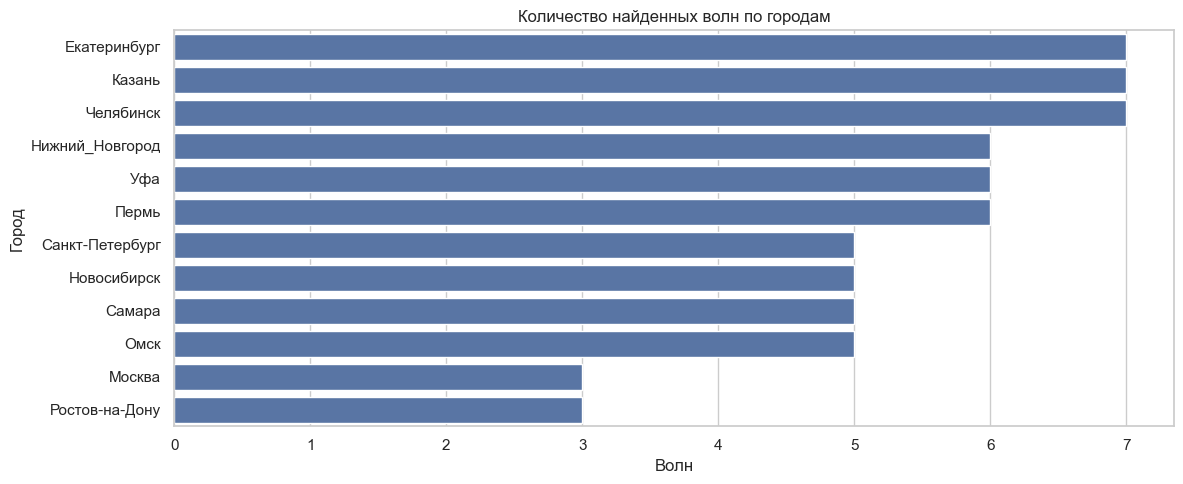

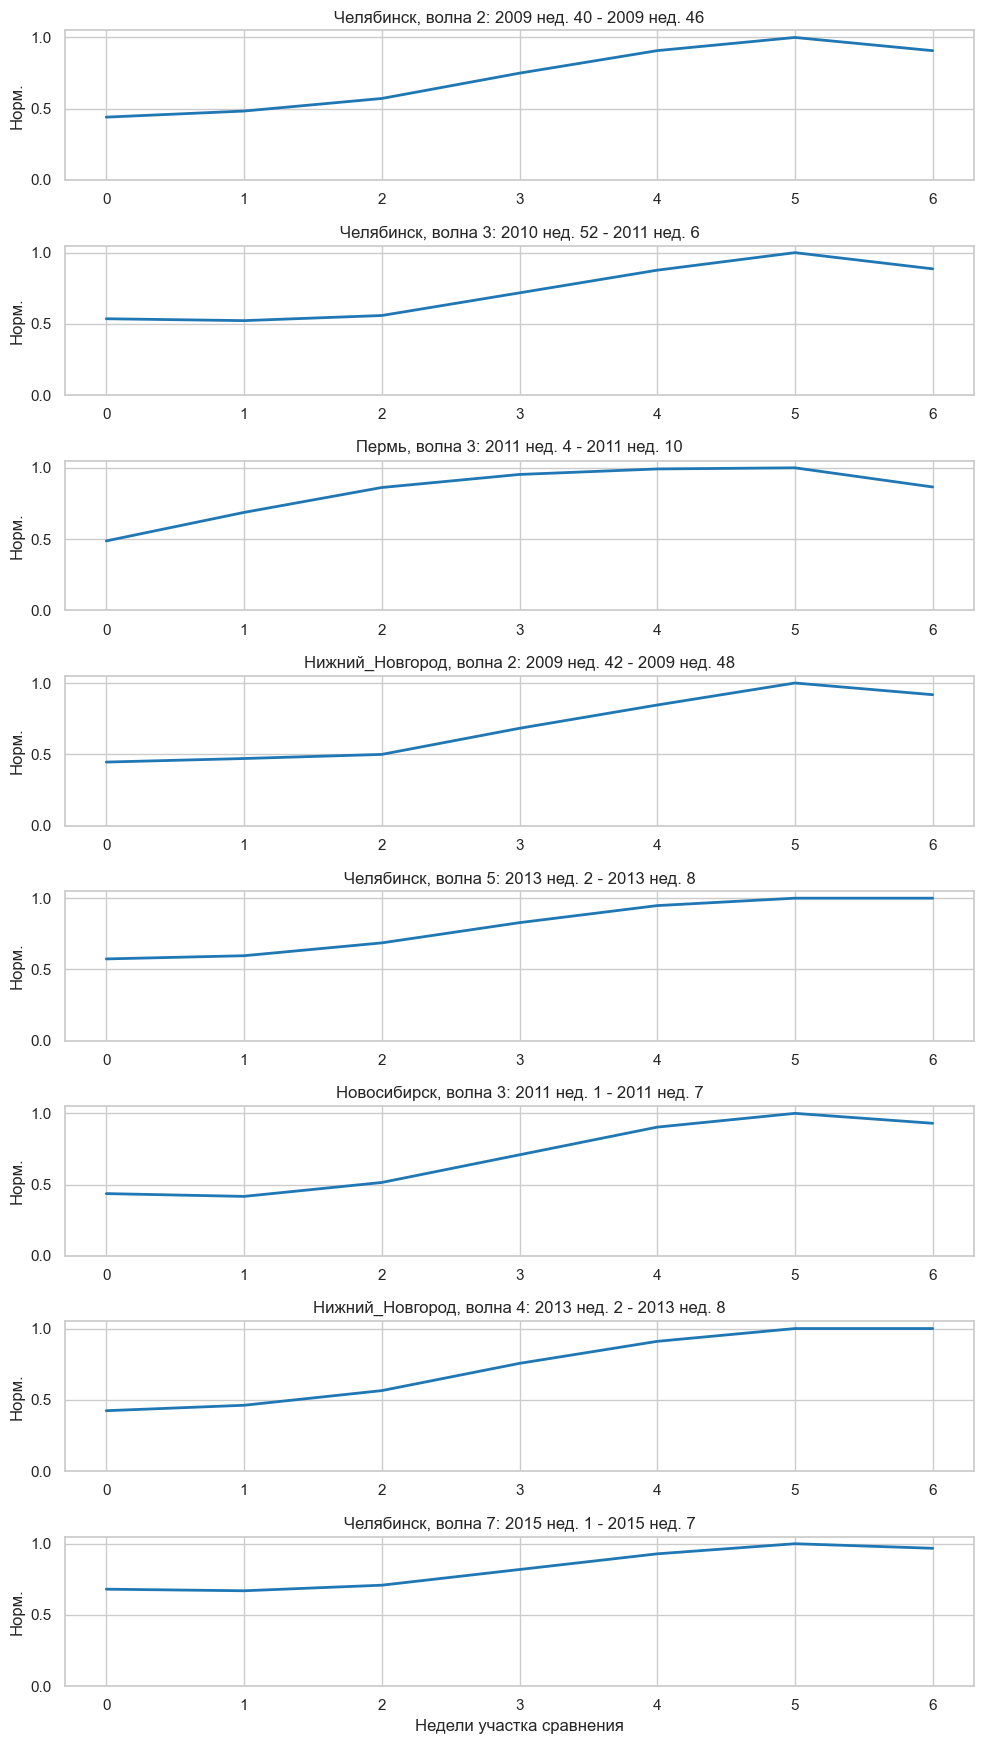

In [52]:
if city_waves.empty:
    print('Городские волны не найдены.')
else:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=city_waves, y='city', order=city_waves['city'].value_counts().index)
    plt.title('Количество найденных волн по городам')
    plt.xlabel('Волн')
    plt.ylabel('Город')
    plt.tight_layout()
    plt.show()

    example_waves = city_waves.sort_values('peak_value_city_series', ascending=False).head(8)
    curve_lookup = {(item['city'], item['wave_id']): item['curve'] for item in city_wave_curves}

    fig, axes = plt.subplots(len(example_waves), 1, figsize=(10, max(4, 2.2 * len(example_waves))), sharex=False)
    if len(example_waves) == 1:
        axes = [axes]

    for ax, row in zip(axes, example_waves.itertuples(index=False)):
        curve = normalize_curve(curve_lookup[(row.city, row.wave_id)])
        ax.plot(curve, color='#1f77b4', linewidth=2)
        ax.set_ylim(0, 1.05)
        ax.set_title(f'{row.city}, волна {row.wave_id}: {row.comparison_start_year} нед. {row.comparison_start_week} - {row.comparison_end_year} нед. {row.comparison_end_week}')
        ax.set_ylabel('Норм.')

    axes[-1].set_xlabel('Недели участка сравнения')
    plt.tight_layout()
    plt.show()

## 12. Сравнение городских волн с синтетикой

Вероятности ниже — это сходство формы с синтетическими кривыми, а не доказанные метки реальной городской топологии.

In [53]:
city_X = city_waves[MODEL_FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
city_proba = best_model.predict_proba(city_X)
city_class = best_model.predict(city_X)
class_to_index = {label: idx for idx, label in enumerate(best_model.classes_)}

city_results = city_waves[[
    'city', 'wave_id',
    'comparison_start_year', 'comparison_start_week', 'comparison_end_year', 'comparison_end_week',
    'start_year', 'start_week', 'end_year', 'end_week', 'peak_year', 'peak_week',
]].copy()

city_results['most_similar_synthetic_class'] = city_class
city_results['ba_shape_similarity'] = city_proba[:, class_to_index['barabasi_albert_graph']]
city_results['watts_shape_similarity'] = city_proba[:, class_to_index['watts_strogatz_graph']]
city_results['similarity_confidence'] = city_proba.max(axis=1)

duplicated_intervals = city_results.duplicated(
    ['city', 'comparison_start_year', 'comparison_start_week', 'comparison_end_year', 'comparison_end_week'],
    keep=False,
)
if duplicated_intervals.any():
    display(city_results.loc[duplicated_intervals].sort_values(['city', 'start_year', 'start_week']))
    raise AssertionError('После удаления пересечений остались дублирующиеся городские интервалы сравнения.')

city_summary = city_results.groupby('city').agg(
    n_waves=('wave_id', 'count'),
    ba_like_share=('ba_shape_similarity', lambda x: np.mean(x >= 0.5)),
    watts_like_share=('watts_shape_similarity', lambda x: np.mean(x >= 0.5)),
    mean_ba_shape_similarity=('ba_shape_similarity', 'mean'),
    mean_watts_shape_similarity=('watts_shape_similarity', 'mean'),
    mean_similarity_confidence=('similarity_confidence', 'mean'),
).reset_index().sort_values('mean_ba_shape_similarity', ascending=False)

print('Сходство на уровне отдельных волн:')
display(city_results.sort_values(['city', 'wave_id']).head(30))
print('Сводка по городам:')
display(city_summary)

Сходство на уровне отдельных волн:


,city,wave_id,comparison_start_year,comparison_start_week,comparison_end_year,comparison_end_week,start_year,start_week,end_year,end_week,peak_year,peak_week,most_similar_synthetic_class,ba_shape_similarity,watts_shape_similarity,similarity_confidence
0,Екатеринбург,1,2009,4,2009,10,2009,4,2009,10,2009,9,barabasi_albert_graph,1.000000,8.236600e-10,1.000000
1,Екатеринбург,2,2009,41,2009,47,2009,41,2009,47,2009,46,barabasi_albert_graph,1.000000,2.300419e-12,1.000000
2,Екатеринбург,3,2010,45,2010,51,2010,45,2010,51,2010,50,barabasi_albert_graph,0.999968,3.192607e-05,0.999968
3,Екатеринбург,4,2011,2,2011,8,2011,2,2011,8,2011,7,barabasi_albert_graph,1.000000,7.337249e-10,1.000000
4,Екатеринбург,5,2013,1,2013,7,2013,1,2013,7,2013,6,barabasi_albert_graph,0.999999,5.428816e-07,0.999999
5,Екатеринбург,6,2014,5,2014,11,2014,5,2014,11,2014,10,barabasi_albert_graph,1.000000,8.013328e-08,1.000000
6,Екатеринбург,7,2015,2,2015,8,2015,2,2015,8,2015,7,barabasi_albert_graph,1.000000,8.859616e-10,1.000000
7,Казань,1,2009,3,2009,9,2009,3,2009,9,2009,8,barabasi_albert_graph,1.000000,1.525346e-10,1.000000
8,Казань,2,2009,42,2009,48,2009,42,2009,48,2009,47,barabasi_albert_graph,1.000000,4.391409e-12,1.000000
9,Казань,3,2010,46,2010,52,2010,46,2010,52,2010,51,barabasi_albert_graph,0.999996,3.708614e-06,0.999996


Сводка по городам:


,city,n_waves,ba_like_share,watts_like_share,mean_ba_shape_similarity,mean_watts_shape_similarity,mean_similarity_confidence
8,Самара,5,1.0,0.0,1.000000,1.217505e-08,1.000000
10,Уфа,6,1.0,0.0,1.000000,8.653063e-08,1.000000
6,Пермь,6,1.0,0.0,1.000000,1.910761e-07,1.000000
2,Москва,3,1.0,0.0,0.999999,5.537096e-07,0.999999
9,Санкт-Петербург,5,1.0,0.0,0.999999,9.094832e-07,0.999999
4,Новосибирск,5,1.0,0.0,0.999998,2.467504e-06,0.999998
5,Омск,5,1.0,0.0,0.999996,3.668460e-06,0.999996
7,Ростов-на-Дону,3,1.0,0.0,0.999996,4.248741e-06,0.999996
0,Екатеринбург,7,1.0,0.0,0.999995,4.650219e-06,0.999995
11,Челябинск,7,1.0,0.0,0.999612,3.880285e-04,0.999612


## 13. Итоговые графики

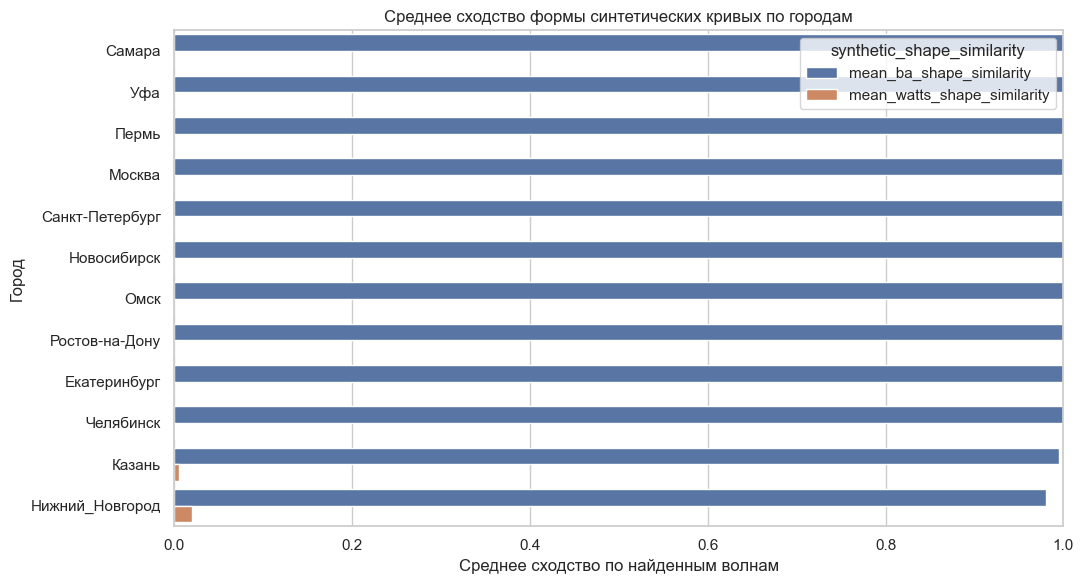

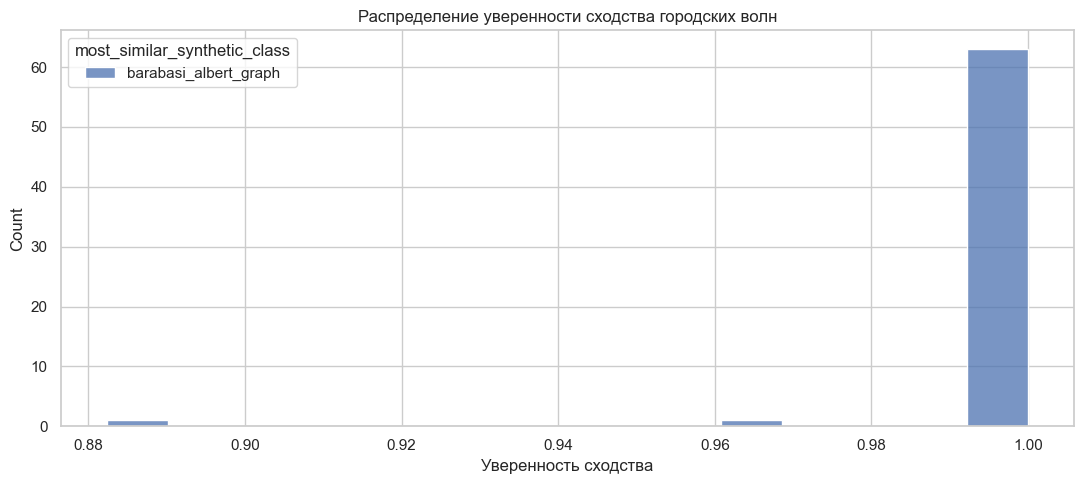

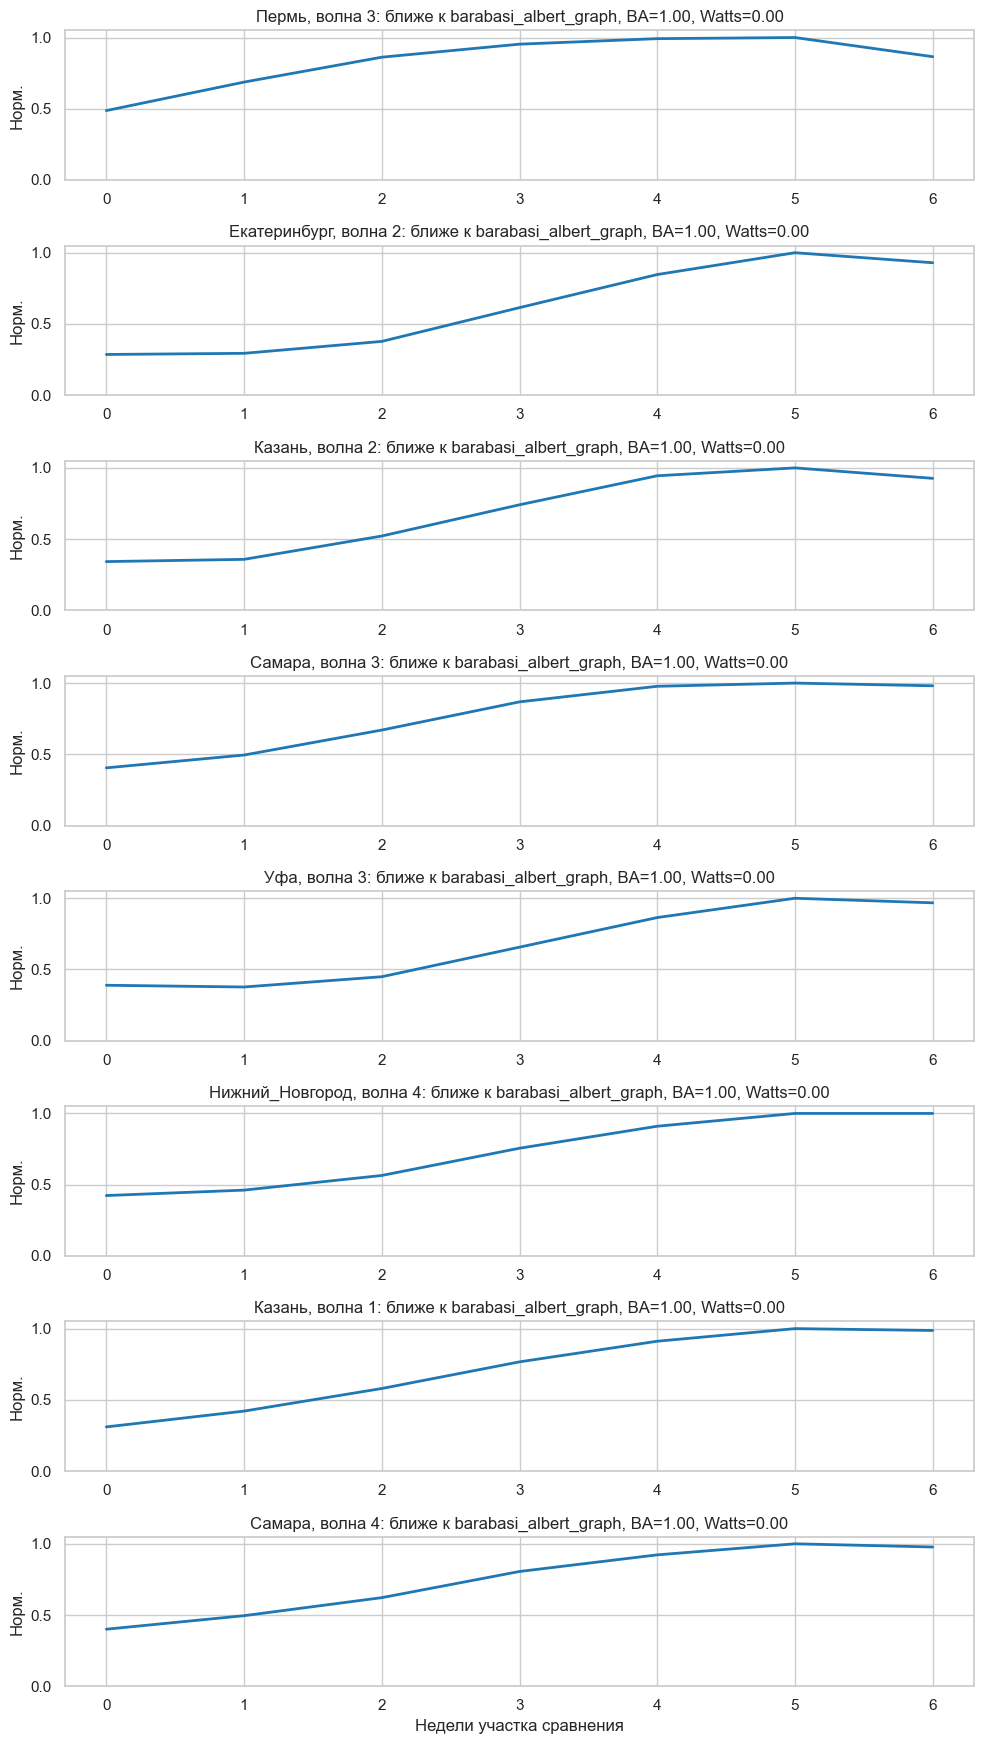

In [54]:
plot_df = city_summary.melt(
    id_vars='city',
    value_vars=['mean_ba_shape_similarity', 'mean_watts_shape_similarity'],
    var_name='synthetic_shape_similarity',
    value_name='mean_similarity',
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x='mean_similarity', y='city', hue='synthetic_shape_similarity')
plt.title('Среднее сходство формы синтетических кривых по городам')
plt.xlabel('Среднее сходство по найденным волнам')
plt.ylabel('Город')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.histplot(data=city_results, x='similarity_confidence', hue='most_similar_synthetic_class', bins=15, multiple='stack')
plt.title('Распределение уверенности сходства городских волн')
plt.xlabel('Уверенность сходства')
plt.tight_layout()
plt.show()

top_examples = city_results.sort_values('similarity_confidence', ascending=False).head(8)
curve_lookup = {(item['city'], item['wave_id']): item['curve'] for item in city_wave_curves}

fig, axes = plt.subplots(len(top_examples), 1, figsize=(10, max(4, 2.2 * len(top_examples))), sharex=False)
if len(top_examples) == 1:
    axes = [axes]

for ax, row in zip(axes, top_examples.itertuples(index=False)):
    curve = normalize_curve(curve_lookup[(row.city, row.wave_id)])
    ax.plot(curve, color='#1f77b4', linewidth=2)
    ax.set_ylim(0, 1.05)
    ax.set_title(
        f'{row.city}, волна {row.wave_id}: ближе к {row.most_similar_synthetic_class}, '
        f'BA={row.ba_shape_similarity:.2f}, Watts={row.watts_shape_similarity:.2f}'
    )
    ax.set_ylabel('Норм.')

axes[-1].set_xlabel('Недели участка сравнения')
plt.tight_layout()
plt.show()

## 14. Как читать результат

- Модель обучена только на форме раннего участка синтетических кривых: небольшой фон перед ростом и рост до пика.
- ba_shape_similarity и watts_shape_similarity показывают сходство городской волны с двумя синтетическими классами.
- Это не прямое восстановление городской сетевой топологии, а аккуратное сравнение формы наблюдаемой волны с формами, полученными в симуляциях.